# Projeto 1 - EDA DataSUS: Morbidade Hospitalar no Amazonas

Este notebook faz uma análise exploratória dos dados de Morbidade Hospitalar do SUS (SIH/SUS) para o estado do Amazonas, obtidos via TABNET/DataSUS.

Fonte principal: [DATASUS - Morbidade Hospitalar do SUS (SIH/SUS)](https://datasus.saude.gov.br/acesso-a-informacao/morbidade-hospitalar-do-sus-sih-sus/).

Os CSVs em `data/raw/` foram baixados com `scripts/download_tabnet.py`, usando o formulário TABNET de morbidade hospitalar por local de residência para Amazonas.

## Objetivos

- Limpar dados exportados do TABNET, tratando valores nulos, tipos incorretos, totais e entidades HTML.
- Analisar internações por município, faixa etária e ano.
- Visualizar padrões com Seaborn/Matplotlib.
- Registrar uma conclusão interpretativa: **O que os dados revelam?**

In [1]:
from pathlib import Path
import html

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RAW_DIR

WindowsPath('C:/Users/nicolas/OneDrive/Área de Trabalho/projeto dados/data/raw')

## Carregamento e limpeza

Os arquivos do TABNET vêm com metadados iniciados por `#`, nomes com entidades HTML e alguns valores ausentes representados por `-`. A função abaixo padroniza esses pontos e transforma as tabelas largas por ano em formato longo.

In [2]:
def normalizar_valor(serie: pd.Series) -> pd.Series:
    return pd.to_numeric(
        serie.astype(str)
        .str.strip()
        .str.replace("-", "0", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce",
    )


def carregar_tabnet(nome_arquivo: str, dimensao: str, valor_nome: str) -> pd.DataFrame:
    caminho = RAW_DIR / nome_arquivo
    df = pd.read_csv(caminho, comment="#", encoding="utf-8-sig")
    df.columns = [html.unescape(str(col)).strip() for col in df.columns]
    df = df.rename(columns={df.columns[0]: dimensao})
    df[dimensao] = df[dimensao].map(lambda x: html.unescape(str(x)).strip())

    df = df[~df[dimensao].str.upper().eq("TOTAL")].copy()
    anos = [col for col in df.columns if str(col).isdigit()]

    longo = df.melt(
        id_vars=dimensao,
        value_vars=anos,
        var_name="ano",
        value_name=valor_nome,
    )
    longo["ano"] = longo["ano"].astype(int)
    longo[valor_nome] = normalizar_valor(longo[valor_nome]).fillna(0)
    return longo


internacoes_municipio = carregar_tabnet(
    "internacoes_municipio_ano_am.csv",
    dimensao="municipio_raw",
    valor_nome="internacoes",
)
obitos_municipio = carregar_tabnet(
    "obitos_municipio_ano_am.csv",
    dimensao="municipio_raw",
    valor_nome="obitos",
)
internacoes_faixa = carregar_tabnet(
    "internacoes_faixa_etaria_ano_am.csv",
    dimensao="faixa_etaria",
    valor_nome="internacoes",
)
taxa_faixa = carregar_tabnet(
    "taxa_mortalidade_faixa_etaria_ano_am.csv",
    dimensao="faixa_etaria",
    valor_nome="taxa_mortalidade",
)

internacoes_municipio.head()

,municipio_raw,ano,internacoes
0,130002 ALVARAES,2020,12
1,130006 AMATURA,2020,9
2,130008 ANAMA,2020,8
3,130010 ANORI,2020,18
4,130014 APUI,2020,8


In [3]:
def separar_codigo_municipio(df: pd.DataFrame) -> pd.DataFrame:
    saida = df.copy()
    extraido = saida["municipio_raw"].str.extract(r"^(?P<codigo_municipio>\d{6})\s+(?P<municipio>.+)$")
    saida["codigo_municipio"] = extraido["codigo_municipio"]
    saida["municipio"] = extraido["municipio"].fillna(saida["municipio_raw"]).str.title()
    return saida.drop(columns=["municipio_raw"])


internacoes_municipio = separar_codigo_municipio(internacoes_municipio)
obitos_municipio = separar_codigo_municipio(obitos_municipio)

faixa_ordem = [
    "Menor 1 ano",
    "1 a 4 anos",
    "5 a 9 anos",
    "10 a 14 anos",
    "15 a 19 anos",
    "20 a 29 anos",
    "30 a 39 anos",
    "40 a 49 anos",
    "50 a 59 anos",
    "60 a 69 anos",
    "70 a 79 anos",
    "80 anos e mais",
    "Idade ignorada",
]

for df in [internacoes_faixa, taxa_faixa]:
    df["faixa_etaria"] = pd.Categorical(df["faixa_etaria"], categories=faixa_ordem, ordered=True)

# A consulta usa arquivos de processamento de Jan/2021 a Fev/2026. Como 2026 está incompleto,
# a análise anual principal usa anos completos de atendimento: 2021 a 2025.
anos_analise = list(range(2021, 2026))

internacoes_municipio = internacoes_municipio[internacoes_municipio["ano"].isin(anos_analise)].copy()
obitos_municipio = obitos_municipio[obitos_municipio["ano"].isin(anos_analise)].copy()
internacoes_faixa = internacoes_faixa[internacoes_faixa["ano"].isin(anos_analise)].copy()
taxa_faixa = taxa_faixa[taxa_faixa["ano"].isin(anos_analise)].copy()

dados_municipio = internacoes_municipio.merge(
    obitos_municipio,
    on=["codigo_municipio", "municipio", "ano"],
    how="left",
)
dados_municipio["obitos"] = dados_municipio["obitos"].fillna(0)
dados_municipio["taxa_mortalidade"] = np.where(
    dados_municipio["internacoes"] > 0,
    dados_municipio["obitos"] / dados_municipio["internacoes"] * 100,
    0,
)

dados_municipio.head()

,ano,internacoes,codigo_municipio,municipio,obitos,taxa_mortalidade
0,2021,681,130002,Alvaraes,18,2.643172
1,2021,362,130006,Amatura,6,1.657459
2,2021,649,130008,Anama,5,0.770416
3,2021,818,130010,Anori,13,1.589242
4,2021,1035,130014,Apui,24,2.318841


### Checagem de qualidade

Aqui verificamos nulos, tipos, duplicatas e a consistência básica das chaves. A ausência de internações em uma combinação município-ano foi mantida como zero quando o TABNET usou `-`.

In [4]:
resumo_limpeza = pd.DataFrame(
    {
        "dataset": [
            "dados_municipio",
            "internacoes_faixa",
            "taxa_faixa",
        ],
        "linhas": [
            len(dados_municipio),
            len(internacoes_faixa),
            len(taxa_faixa),
        ],
        "nulos": [
            int(dados_municipio.isna().sum().sum()),
            int(internacoes_faixa.isna().sum().sum()),
            int(taxa_faixa.isna().sum().sum()),
        ],
        "duplicatas": [
            int(dados_municipio.duplicated(["codigo_municipio", "ano"]).sum()),
            int(internacoes_faixa.duplicated(["faixa_etaria", "ano"]).sum()),
            int(taxa_faixa.duplicated(["faixa_etaria", "ano"]).sum()),
        ],
    }
)

resumo_limpeza

,dataset,linhas,nulos,duplicatas
0,dados_municipio,310,0,0
1,internacoes_faixa,60,0,0
2,taxa_faixa,60,0,0


In [5]:
dados_municipio.to_csv(PROCESSED_DIR / "internacoes_obitos_municipio_ano_am_limpo.csv", index=False)
internacoes_faixa.to_csv(PROCESSED_DIR / "internacoes_faixa_etaria_ano_am_limpo.csv", index=False)
taxa_faixa.to_csv(PROCESSED_DIR / "taxa_mortalidade_faixa_etaria_ano_am_limpo.csv", index=False)

dados_municipio.dtypes

ano                   int64
internacoes           int64
codigo_municipio     object
municipio            object
obitos                int64
taxa_mortalidade    float64
dtype: object

## Análise por ano

In [6]:
resumo_ano = (
    dados_municipio.groupby("ano", as_index=False)
    .agg(internacoes=("internacoes", "sum"), obitos=("obitos", "sum"))
)
resumo_ano["taxa_mortalidade"] = resumo_ano["obitos"] / resumo_ano["internacoes"] * 100
resumo_ano

,ano,internacoes,obitos,taxa_mortalidade
0,2021,215288,11727,5.447122
1,2022,213892,7456,3.485871
2,2023,216155,7039,3.256459
3,2024,230844,7348,3.183102
4,2025,261018,7871,3.015501


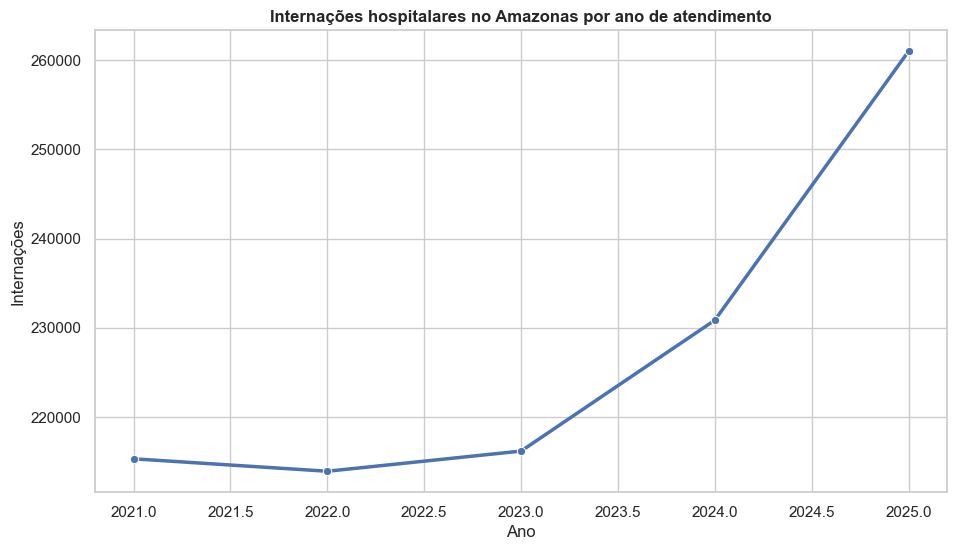

In [7]:
fig, ax = plt.subplots()
sns.lineplot(data=resumo_ano, x="ano", y="internacoes", marker="o", linewidth=2.5, ax=ax)
ax.set_title("Internações hospitalares no Amazonas por ano de atendimento")
ax.set_xlabel("Ano")
ax.set_ylabel("Internações")
ax.ticklabel_format(style="plain", axis="y")
fig.savefig(PROCESSED_DIR / "internacoes_ano.png", dpi=150, bbox_inches="tight")
plt.show()

## Análise por município

In [8]:
top_municipios = (
    dados_municipio.groupby("municipio", as_index=False)
    .agg(internacoes=("internacoes", "sum"), obitos=("obitos", "sum"))
    .sort_values("internacoes", ascending=False)
    .head(10)
)
top_municipios["participacao_internacoes_%"] = (
    top_municipios["internacoes"] / dados_municipio["internacoes"].sum() * 100
)
top_municipios

,municipio,internacoes,obitos,participacao_internacoes_%
37,Manaus,600501,29011,52.805363
45,Parintins,39696,1166,3.490688
35,Manacapuru,34988,1055,3.076688
28,Itacoatiara,29979,998,2.636219
57,Tefe,28217,497,2.481276
19,Coari,23638,924,2.078620
40,Maues,17808,530,1.565956
25,Humaita,13945,368,1.226261
12,Boca Do Acre,12569,239,1.105261
38,Manicore,12161,284,1.069384


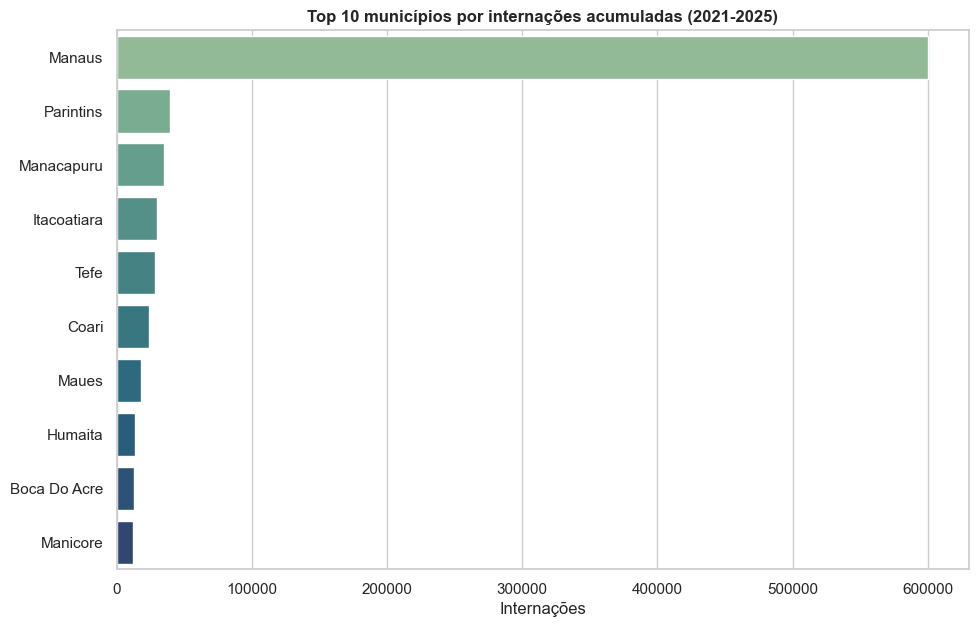

In [9]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=top_municipios,
    y="municipio",
    x="internacoes",
    hue="municipio",
    legend=False,
    palette="crest",
    ax=ax,
)
ax.set_title("Top 10 municípios por internações acumuladas (2021-2025)")
ax.set_xlabel("Internações")
ax.set_ylabel("")
ax.ticklabel_format(style="plain", axis="x")
fig.savefig(PROCESSED_DIR / "internacoes_municipio.png", dpi=150, bbox_inches="tight")
plt.show()

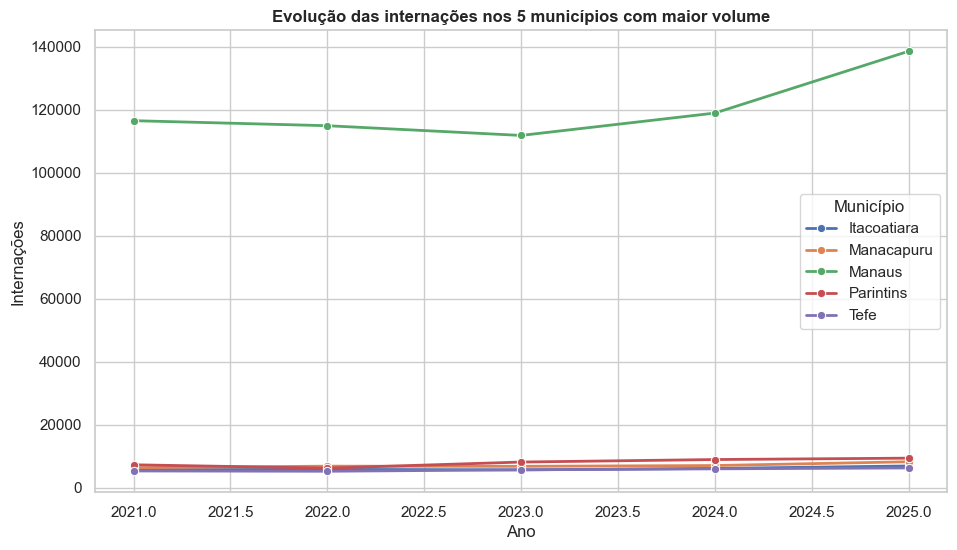

In [10]:
top5 = top_municipios["municipio"].head(5)
serie_top5 = dados_municipio[dados_municipio["municipio"].isin(top5)]

fig, ax = plt.subplots()
sns.lineplot(
    data=serie_top5,
    x="ano",
    y="internacoes",
    hue="municipio",
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.set_title("Evolução das internações nos 5 municípios com maior volume")
ax.set_xlabel("Ano")
ax.set_ylabel("Internações")
ax.ticklabel_format(style="plain", axis="y")
plt.legend(title="Município")
fig.savefig(PROCESSED_DIR / "evolucao_top5_municipios.png", dpi=150, bbox_inches="tight")
plt.show()

## Análise por faixa etária

In [11]:
resumo_faixa = (
    internacoes_faixa.groupby("faixa_etaria", observed=True, as_index=False)
    .agg(internacoes=("internacoes", "sum"))
    .sort_values("faixa_etaria")
)
resumo_faixa["participacao_%"] = resumo_faixa["internacoes"] / resumo_faixa["internacoes"].sum() * 100
resumo_faixa

,faixa_etaria,internacoes,participacao_%
0,Menor 1 ano,73491,6.462469
1,1 a 4 anos,65647,5.772703
2,5 a 9 anos,39161,3.443643
3,10 a 14 anos,32752,2.880064
4,15 a 19 anos,99977,8.791529
5,20 a 29 anos,251760,22.138644
6,30 a 39 anos,166569,14.647330
7,40 a 49 anos,111750,9.826793
8,50 a 59 anos,94284,8.290912
9,60 a 69 anos,94774,8.334000


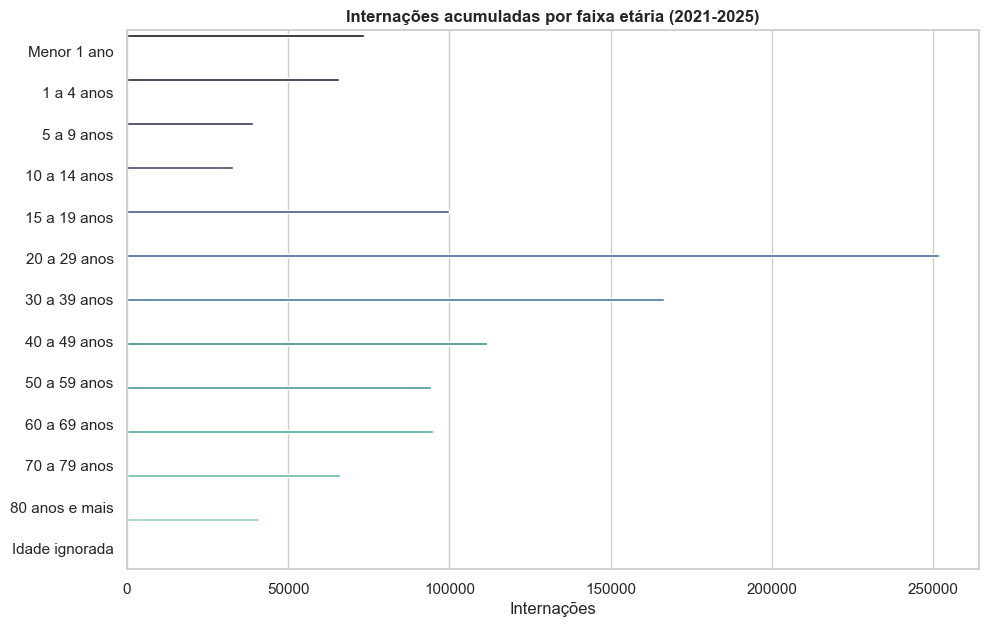

In [12]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=resumo_faixa,
    y="faixa_etaria",
    x="internacoes",
    hue="faixa_etaria",
    legend=False,
    palette="mako",
    ax=ax,
)
ax.set_title("Internações acumuladas por faixa etária (2021-2025)")
ax.set_xlabel("Internações")
ax.set_ylabel("")
ax.ticklabel_format(style="plain", axis="x")
fig.savefig(PROCESSED_DIR / "internacoes_faixa_etaria.png", dpi=150, bbox_inches="tight")
plt.show()

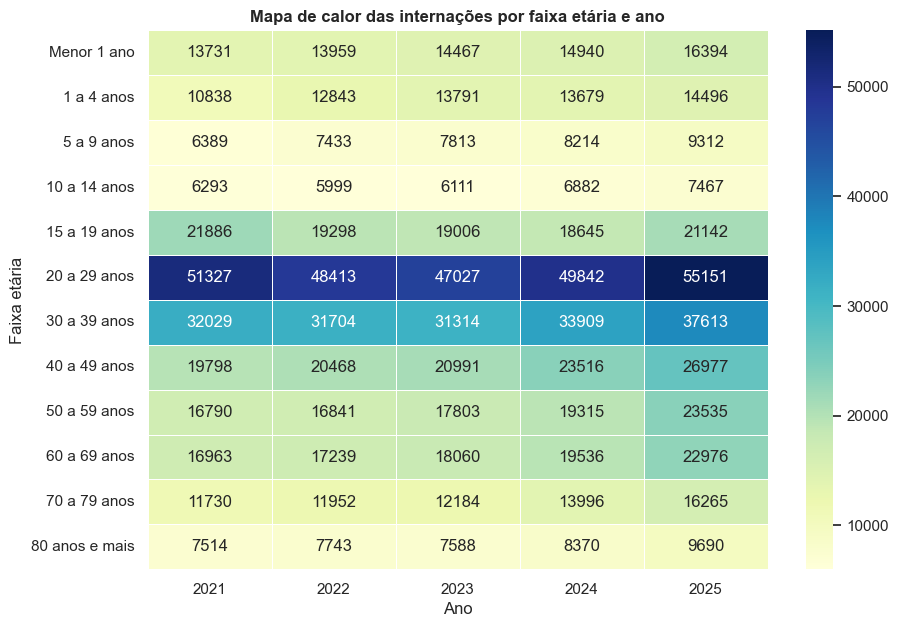

In [13]:
matriz_faixa_ano = (
    internacoes_faixa.pivot_table(
        index="faixa_etaria",
        columns="ano",
        values="internacoes",
        aggfunc="sum",
        observed=True,
    )
    .reindex(faixa_ordem)
    .dropna(how="all")
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(matriz_faixa_ano, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_title("Mapa de calor das internações por faixa etária e ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Faixa etária")
fig.savefig(PROCESSED_DIR / "heatmap_faixa_ano.png", dpi=150, bbox_inches="tight")
plt.show()

## Mortalidade

In [14]:
taxa_media_faixa = (
    taxa_faixa.groupby("faixa_etaria", observed=True, as_index=False)
    .agg(taxa_mortalidade_media=("taxa_mortalidade", "mean"))
    .sort_values("faixa_etaria")
)
taxa_media_faixa

,faixa_etaria,taxa_mortalidade_media
0,Menor 1 ano,2.936
1,1 a 4 anos,0.674
2,5 a 9 anos,0.552
3,10 a 14 anos,0.684
4,15 a 19 anos,0.402
5,20 a 29 anos,0.620
6,30 a 39 anos,1.362
7,40 a 49 anos,3.448
8,50 a 59 anos,6.118
9,60 a 69 anos,8.824


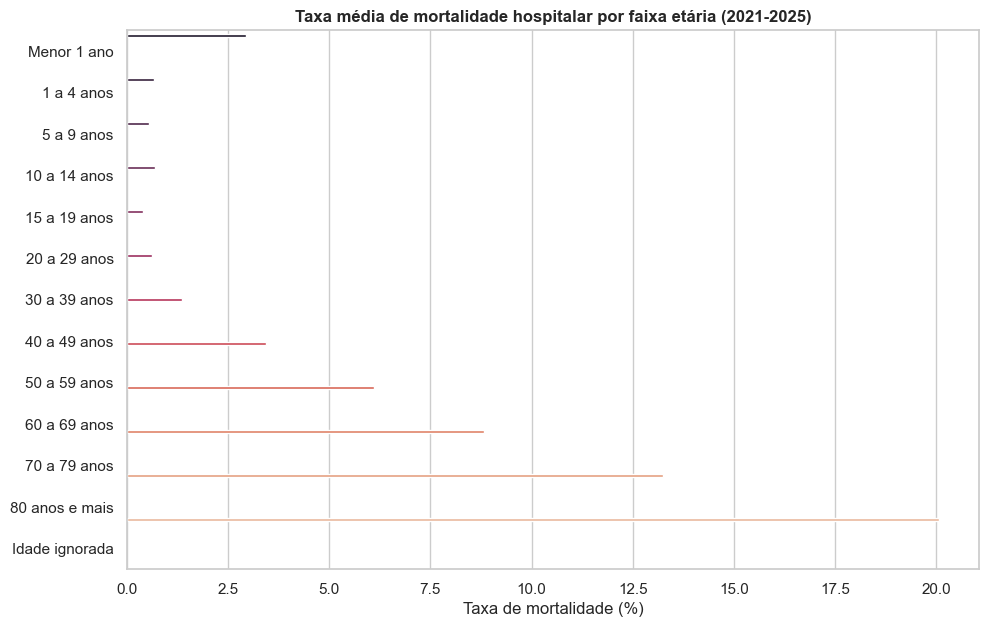

In [15]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=taxa_media_faixa,
    y="faixa_etaria",
    x="taxa_mortalidade_media",
    hue="faixa_etaria",
    legend=False,
    palette="rocket",
    ax=ax,
)
ax.set_title("Taxa média de mortalidade hospitalar por faixa etária (2021-2025)")
ax.set_xlabel("Taxa de mortalidade (%)")
ax.set_ylabel("")
fig.savefig(PROCESSED_DIR / "taxa_mortalidade_faixa_etaria.png", dpi=150, bbox_inches="tight")
plt.show()

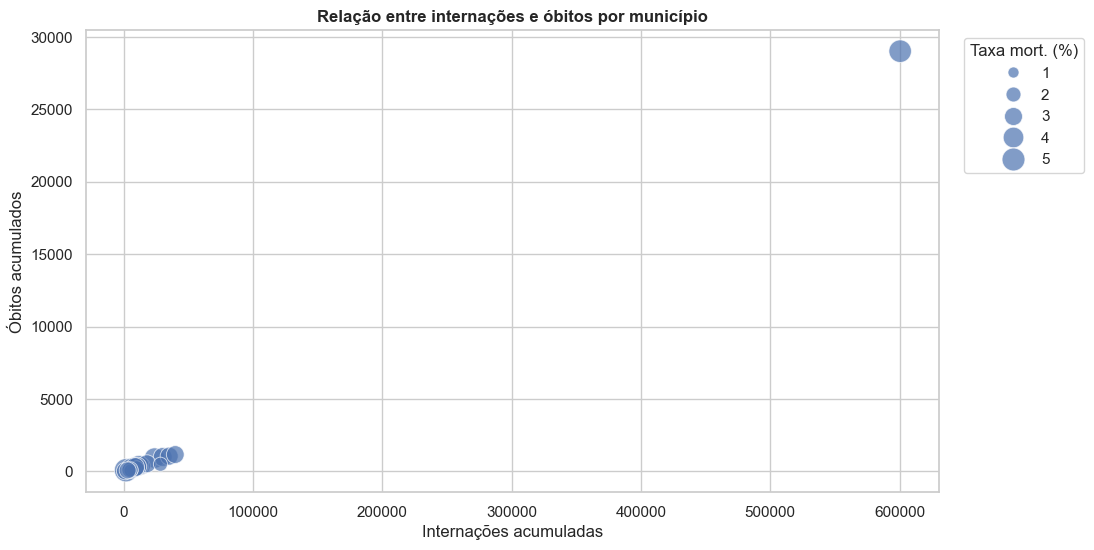

In [16]:
dados_municipio_total = (
    dados_municipio.groupby("municipio", as_index=False)
    .agg(internacoes=("internacoes", "sum"), obitos=("obitos", "sum"))
)
dados_municipio_total["taxa_mortalidade"] = (
    dados_municipio_total["obitos"] / dados_municipio_total["internacoes"] * 100
)

fig, ax = plt.subplots()
sns.scatterplot(
    data=dados_municipio_total,
    x="internacoes",
    y="obitos",
    size="taxa_mortalidade",
    sizes=(30, 280),
    alpha=0.7,
    ax=ax,
)
ax.set_title("Relação entre internações e óbitos por município")
ax.set_xlabel("Internações acumuladas")
ax.set_ylabel("Óbitos acumulados")
ax.ticklabel_format(style="plain")
plt.legend(title="Taxa mort. (%)", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.savefig(PROCESSED_DIR / "internacoes_obitos_municipio.png", dpi=150, bbox_inches="tight")
plt.show()

## Exportação final

Os arquivos abaixo deixam explícita a transformação de dados: os CSVs originais ficam em `data/raw/`, enquanto estes arquivos tratados ficam em `data/processed/`.

In [17]:
dados_municipio.to_csv(PROCESSED_DIR / "municipios_tratados.csv", index=False)
resumo_faixa.to_csv(PROCESSED_DIR / "resumo_faixa_etaria.csv", index=False)

sorted(path.name for path in PROCESSED_DIR.glob("*"))

['evolucao_top5_municipios.png',
 'heatmap_faixa_ano.png',
 'internacoes_ano.png',
 'internacoes_faixa_etaria.png',
 'internacoes_faixa_etaria_ano_am_limpo.csv',
 'internacoes_municipio.png',
 'internacoes_obitos_municipio.png',
 'internacoes_obitos_municipio_ano_am_limpo.csv',
 'municipios_tratados.csv',
 'resumo_faixa_etaria.csv',
 'taxa_mortalidade_faixa_etaria.png',
 'taxa_mortalidade_faixa_etaria_ano_am_limpo.csv']

## O que os dados revelam?

Entre 2021 e 2025, os dados do SIH/SUS indicam **1.137.197 internações hospitalares** de residentes no Amazonas. O volume anual ficou relativamente estável entre 2021 e 2023, cresceu em 2024 e atingiu o maior valor em 2025, com alta de aproximadamente **21,2%** em relação a 2021.

A distribuição municipal é bastante concentrada: **Manaus responde por cerca de 52,8% das internações** do período, seguida por Parintins, Manacapuru, Itacoatiara e Tefé. Esse padrão reflete tanto o peso populacional da capital quanto a centralidade de sua rede assistencial.

Por idade, as faixas de **20 a 29 anos** e **30 a 39 anos** concentram o maior número de internações. Sem cruzar com sexo, diagnóstico ou procedimento, não dá para afirmar a causa, mas o padrão sugere investigar eventos ligados ao ciclo reprodutivo, causas clínicas frequentes em adultos jovens e acesso hospitalar por perfil demográfico.

A mortalidade hospitalar cresce com a idade. As maiores taxas médias aparecem em **80 anos e mais**, **70 a 79 anos** e **60 a 69 anos**, o que é coerente com maior fragilidade clínica e maior gravidade esperada das internações em idosos.

Como o TABNET agrega dados de internações do SUS, os resultados não representam toda a morbidade da população nem internações exclusivamente privadas. Ainda assim, revelam um retrato útil da demanda hospitalar pública e conveniada no Amazonas.